# Extraction Accuracy Report

Compare LLM extractions against gold-standard JSONs:
- Per-paper accuracy metrics
- Error categorization (wrong value, missed value, hallucinated value)
- Accuracy by source type and by prompt

In [4]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT_DIR = Path("..").resolve()
sys.path.insert(0, str(ROOT_DIR))

EXTRACTIONS_DIR = ROOT_DIR / "data" / "extractions"
GOLD_DIR = ROOT_DIR / "data" / "gold_standard"

In [5]:
import sys 
sys.path.insert(0, '../scripts')
from validate import validate_extraction, print_report

# Find papers that have both extraction and gold standard
gold_files = {p.stem.replace("_extraction", ""): p for p in GOLD_DIR.glob("*.json")}
ext_files = {p.stem: p for p in EXTRACTIONS_DIR.glob("*.json")}

matched = set(gold_files.keys()) & set(ext_files.keys())
print(f"Gold standards available: {list(gold_files.keys())}")
print(f"Extractions available: {list(ext_files.keys())}")
print(f"Matched for validation: {list(matched)}")

Gold standards available: ['benabu2018', 'wee2018']
Extractions available: ['schiffman2003', 'benabu2018', 'keast2010']
Matched for validation: ['benabu2018']


## 1. Per-Paper Validation

In [6]:
reports = []
for study_id in sorted(matched):
    with open(ext_files[study_id]) as f:
        extracted = json.load(f)
    with open(gold_files[study_id]) as f:
        gold = json.load(f)
    
    report = validate_extraction(extracted, gold)
    reports.append(report)
    print_report(report)
    print()


📊 Validation Report: benabu2018

  Overall accuracy: 13.6%
  Fields checked: 110
  Correct: 15
  Experiments: 4/3

  Metadata: 87.5% (7/8)
    ✗ food_category: got 'salt substitute solutions', expected 'salt substitute solutions / taste interaction'

  benabu2018_exp1: 8.3% (4/48)
    ✗ stimuli.count: got 0, expected 14
    ✗ ..raw_scores: got N/A, expected N/A
    ✗ ..relative_perceptions: got N/A, expected N/A
    ✗ ..sweetness_of_pure_sugars: got N/A, expected N/A

  benabu2018_exp2: 5.4% (2/37)
    ✗ stimuli.count: got 0, expected 7
    ✗ ..raw_scores: got N/A, expected N/A
    ✗ ..relative_perceptions: got N/A, expected N/A

  benabu2018_exp3: 11.8% (2/17)
    ✗ stimuli.count: got 0, expected 5
    ✗ ..relative_perceptions: got N/A, expected N/A

  Structural errors:
    ✗ Extracted experiment 3 not in gold standard



## 2. Accuracy Summary

  study_id  overall_accuracy  metadata_accuracy  fields_checked  correct  num_errors
benabu2018          0.136364              0.875             110       15          95


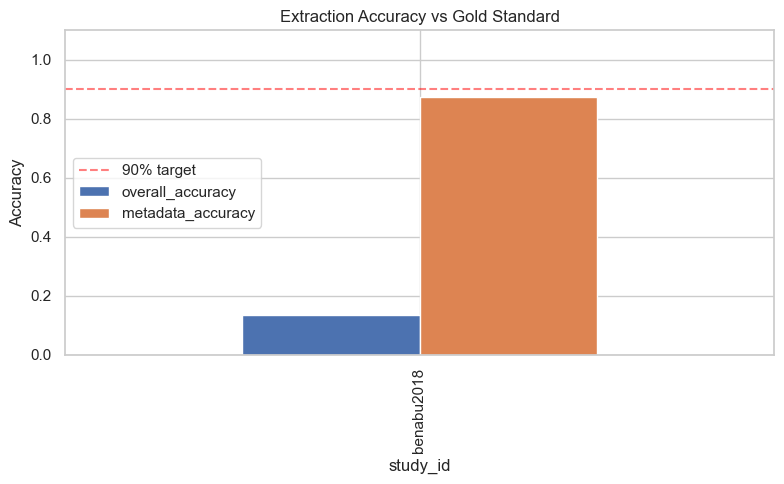

In [7]:
if reports:
    summary_data = []
    for r in reports:
        summary_data.append({
            "study_id": r["study_id"],
            "overall_accuracy": r["overall_accuracy"],
            "metadata_accuracy": r["metadata_accuracy"]["accuracy"],
            "fields_checked": r["summary"]["total_fields_checked"],
            "correct": r["summary"]["correct_fields"],
            "num_errors": r["summary"]["total_fields_checked"] - r["summary"]["correct_fields"],
        })
    
    df_summary = pd.DataFrame(summary_data)
    print(df_summary.to_string(index=False))
    
    # Plot accuracy
    if len(df_summary) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        df_summary.plot(x="study_id", y=["overall_accuracy", "metadata_accuracy"],
                        kind="bar", ax=ax)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel("Accuracy")
        ax.set_title("Extraction Accuracy vs Gold Standard")
        ax.axhline(y=0.9, color="red", linestyle="--", alpha=0.5, label="90% target")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No matched papers for validation yet. Run the pipeline first.")

## 3. Error Categorization

In [8]:
all_errors = []
for r in reports:
    # Metadata errors
    for err in r["metadata_accuracy"].get("errors", []):
        err["study_id"] = r["study_id"]
        err["section"] = "metadata"
        all_errors.append(err)
    
    # Experiment errors
    for exp_r in r.get("experiment_accuracy", []):
        for err in exp_r.get("errors", []):
            err["study_id"] = r["study_id"]
            all_errors.append(err)

if all_errors:
    df_errors = pd.DataFrame(all_errors)
    print(f"Total errors: {len(df_errors)}")
    
    if "type" in df_errors.columns:
        print(f"\nErrors by type:")
        print(df_errors["type"].value_counts().to_string())
    
    if "section" in df_errors.columns:
        print(f"\nErrors by section:")
        print(df_errors["section"].value_counts().to_string())
else:
    print("No errors to analyze yet.")

Total errors: 10

Errors by type:
missing_key    6
wrong_value    1

Errors by section:
stimuli     3
metadata    1
